## 1. Загрузка данных и первичный анализ

### 1.1. Загрузка датасета

In [ ]:
# Загрузите все необходимые библиотеки и датасет
# Выведите первые 5 строк датасета
import pandas as pd
import numpy as np

# Выводим первые 5 строк
df = pd.read_excel("3_Concrete_Data.xls")
print(df.head())


*(Кратко прокомментируйте, какие признаки есть в данных и что является целевой переменной.)*

Признаки: Cement, BlastFurnaceSlag, FlyAsh, Water, Superplasticizer, CoarseAggregate, FineAggregate, Age
Целевая переменная: csMPa (прочность бетона на сжатие)

### 1.2. Размерность и описательные статистики

In [9]:
# получите размерность датасета
print(f"Строк: {df.shape[0]}, Столбцов: {df.shape[1]}")


Строк: 1030, Столбцов: 9


In [ ]:
# получите описательные статистики датасета
print(df.describe())



Комментарий:

*Напишите 2–3 предложения по итогам первичного анализа.*

В датасете 1030 наблюдений и 9 столбцов. Пропуски отсутствуют, признаки имеют разный масштаб, что потребует нормализации перед обучением модели.

## 2. Признаки с низкой вариацией

### 2.1. Количество уникальных значений

In [ ]:
# посчитайте количество уникальных значений
# выведите количество уникальных значений по столбцам
unique_counts = df.nunique()
print(unique_counts)


### 2.2. Поиск и удаление константных / почти константных признаков

In [ ]:
# Найдите признаки с одной уникальной категорией
# Выведите их количество
counts = df.nunique()
to_del = [i for i, v in enumerate(counts) if v == 1]
print(to_del)

In [ ]:
# Приведите код для удаления колонок с константными признаками
# Выведите обновленную размерность датасета
df.drop(to_del, axis=1, inplace=True)
print(df.shape)


Комментарий:

*Объясните, почему эти признаки не полезны для модели.*

Признаки с одним уникальным значением не несут полезной информации,
так как они одинаковы для всех объектов. Такие признаки не помогают
модели различать объекты, но увеличивают размерность и замедляют обучение.
Поэтому они удаляются на этапе предобработки данных.

## 3. Дубликаты строк

### 3.1. Поиск дубликатов


In [ ]:
# приведите код для поиска дубликатов строк
# выведите общее количество дубликатов строк в датасете
mask_all = df.duplicated(keep=False)
dups_grouped = df[mask_all].sort_values(list(df.columns))
print(dups_grouped)


In [ ]:
# При наличии дубликатов выведите первые 5 строк из повторяющихся значений
mask_all = df.duplicated(keep=False)
dups_grouped = df[mask_all].sort_values(list(df.columns))
print(dups_grouped.head(5))



### 3.2. Удаление дубликатов

In [ ]:
# Удалите дубликаты из датасета
# Проверьте размерность датасета после удаления дубликатов
df.drop_duplicates(inplace=True)
print(df.shape)

Комментарий:

*Опишите, как дубликаты могут повлиять на обучение модели.*

Дубликаты строк могут привести к переобучению модели, так как одинаковые объекты будут иметь больший вес при обучении. Это искажает реальное распределение данных.

## 4. Выбросы

### 4.1. Исследование распределений (по выбору 2–3 признаков)

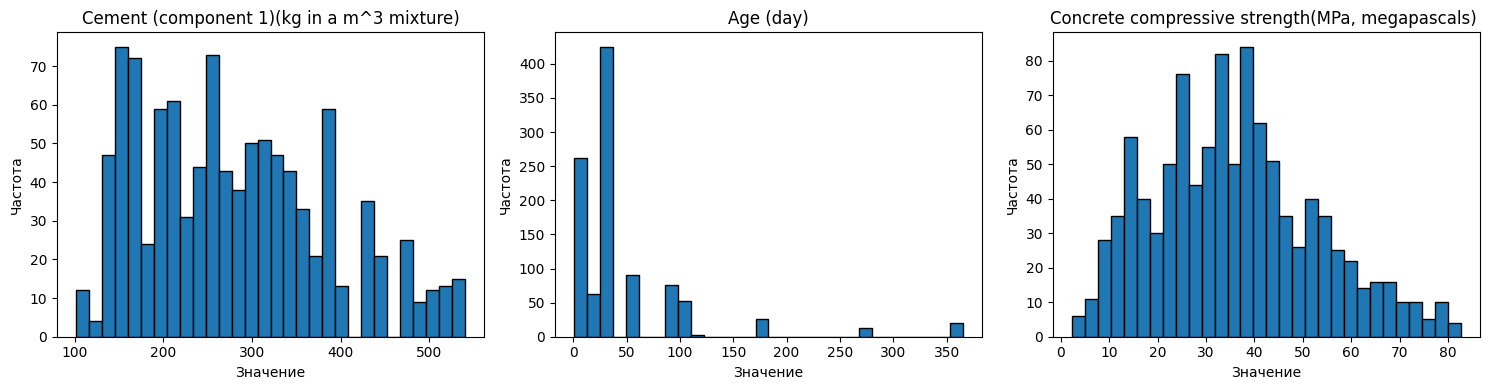

In [8]:
# Приведеите пример гистограммы минимум 3х признаков
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("3_Concrete_Data.xls")

# 3 признака для визуализации
features = [
    'Cement (component 1)(kg in a m^3 mixture)',
    'Age (day)',
    'Concrete compressive strength(MPa, megapascals) '
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, feature in enumerate(features):
    axes[i].hist(df[feature], bins=30, edgecolor='black')
    axes[i].set_title(feature)
    axes[i].set_xlabel('Значение')
    axes[i].set_ylabel('Частота')

plt.tight_layout()
plt.show()

### 4.2. Определение выбросов (3σ или IQR)

In [9]:
# определите верхние и нижние пределы выбросов одним из способов для одного из признаков. 
import pandas as pd

df = pd.read_excel("3_Concrete_Data.xls")

# Для признака 'Age'
q25, q75 = df['Age (day)'].quantile(0.25), df['Age (day)'].quantile(0.75)
iqr = q75 - q25
lower = q25 - 1.5 * iqr
upper = q75 + 1.5 * iqr

print(f"Нижняя граница: {lower:.2f}")
print(f"Верхняя граница: {upper:.2f}")

Нижняя граница: -66.50
Верхняя граница: 129.50


In [10]:
# посчитайте количество выбросов
outliers = df[(df['Age'] < lower) | (df['Age'] > upper)]
print(f"Количество выбросов: {len(outliers)}")

KeyError: 'Age'

*(Повторите аналогичную процедуру для двух других признаков.)*

## 5. Пропуски в данных

### 5.1. Анализ пропусков

In [28]:
# посчитайте количество пропусков по столбцам


### 5.2. Стратегии обработки пропусков

#### Стратегия 1: (например, удаление строк с пропусками)

In [34]:
# приведите код для удаления пропусков
# выведите размер датасета послед удаления пропусков



#### Стратегия 2: (например, простая импутация средним / kNN / IterativeImputer)

In [39]:
# примените один из методов для замены пропущенных значений


Комментарий:

*Обоснуйте выбор стратегии и прокомментируйте ожидаемые эффекты.*

## 6. Построение и оценка моделей

### 6.1. Разбиение на обучающую и тестовую выборки

In [40]:
# импортируйте модуль из библиотеки sklearn для разбиения на обучающую и тестовую выборки
# разбейте все данные на тестовую и обучающую выборки


### 6.2. Модель 1: линейная регрессия

In [45]:
# обучите модель линейной регрессии и посчитайте MAE, RMSE, R2


Комментарий:

*Сделайте краткий вывод о качестве линейной модели.*

### 6.3. Модель 2: более сложная (например, RandomForestRegressor)

In [46]:
# обучите модель случайного леса и посчитайте MAE, RMSE, R2


Комментарий:

*Сравните результаты с линейной моделью. Какие преимущества/недостатки вы видите?*